In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ielādē 2. nedēļas tīro datu kopu
df = pd.read_csv('../week2/shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")

Datu kopa: 12330 rindas, 28 kolonnas


In [2]:
y = df['PageValues']
# Izņemam PageValues (jo tas ir target) un Revenue (lai novērstu noplūdi)
X = df.drop(['PageValues', 'Revenue'], axis=1)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Kāpēc mēs izņēmām kolonnu Revenue un kas ir datu noplūde (Data Leakage)?
Datu noplūde (Data Leakage) ir situācija mašīnmācīšanās procesā, kad modelis trenēšanās laikā saņem informāciju, kas reālajā dzīvē (kad modelis darbosies praksē) tam vēl nebūs pieejama. To var salīdzināt ar atbilžu "špikošanu" pirms eksāmena – modelis testos uzrādīs izcilus rezultātus, bet reālajā pasaulē nestrādās, jo šo "špikeri" vairs nevarēs izmantot.

Kāpēc mēs izņēmām Revenue?
Mūsu mērķis šajā uzdevumā ir prognozēt PageValues (klienta sesijas potenciālo vērtību). Kolonna Revenue norāda uz pašu gala rezultātu – to, vai klients sesijas beigās tiešām kaut ko nopirka. Tā ir "nākotnes" informācija. Reālā e-komercijas situācijā mēs gribam prognozēt klienta vērtību pirms viņš ir pieņēmis lēmumu pirkt vai nepirkt. Ja mēs atstātu Revenue datus savā modelī, tas iemācītos paļauties uz šo nākotnes faktu, izraisītu datu noplūdi, un biznesam no šāda modeļa nebūtu nekādas jēgas.

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

MSE: 0.9892
RMSE: 0.9946
MAE: 0.5009
R2: 0.0456


Modeļa metriku interpretācija -
Ko nozīmē MSE (Mean Squared Error)? MSE jeb vidējā kvadrātiskā kļūda mēra vidējo kvadrātisko atšķirību starp modeļa prognozētajām un faktiskajām vērtībām. Lielākas kļūdas tiek sodītas vairāk, jo tās aprēķinā tiek kāpinātas kvadrātā (piemēram, ja kļūda ir 2, tā dod 4 punktus kļūdas rādītājam, bet ja kļūda ir 10, tā dod 100). Tas palīdz pamanīt, ja modelis bieži pieļauj ļoti rupjas kļūdas.

Ko nozīmē R² (R-squared) un iegūtā vērtība? R² parāda, cik lielu daļu no mērķa mainīgā (PageValues) izmaiņām izskaidro mūsu modelis. Mana iegūtā vērtība ir aptuveni 0.0456, kas nozīmē, ka lineārās regresijas modelis izskaidro tikai apmēram 4.5% no datiem.

Vai modelis ir labs vai slikts? Modelis ir ļoti slikts. R² vērtība ir ārkārtīgi zema. Tas liecina, ka klientu uzvedības dati un lapas vērtība nav vienkāršās, lineārās attiecībās. Lineārā regresija ir pārāk vienkārša šim uzdevumam, tāpēc būs jāizmanto sarežģītāks algoritms.

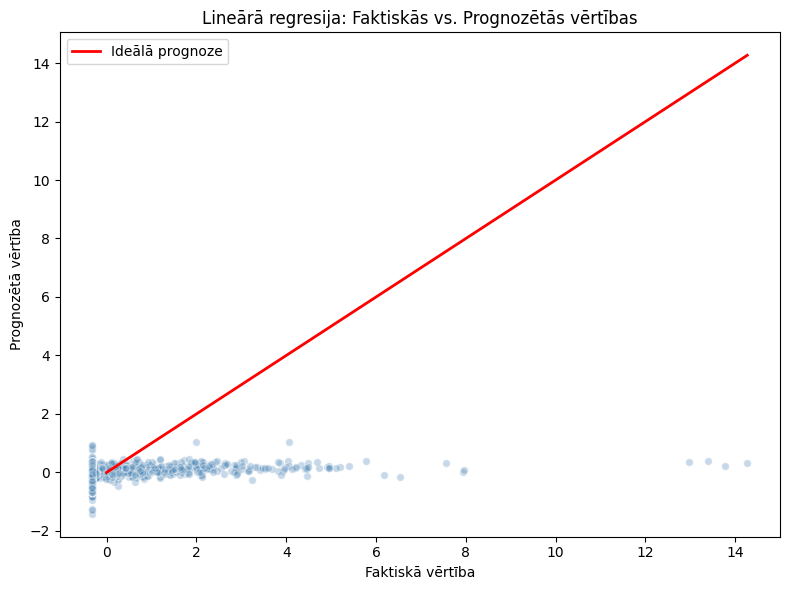

In [4]:
# 3.1. Faktiskās vs. prognozētās vērtības
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='white', s=30)

# Ideālā līnija (ja prognoze = realitāte)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r', linewidth=2, label='Ideālā prognoze')

plt.xlabel('Faktiskā vērtība')
plt.ylabel('Prognozētā vērtība')
plt.title('Lineārā regresija: Faktiskās vs. Prognozētās vērtības')
plt.legend()
plt.tight_layout()
plt.show()

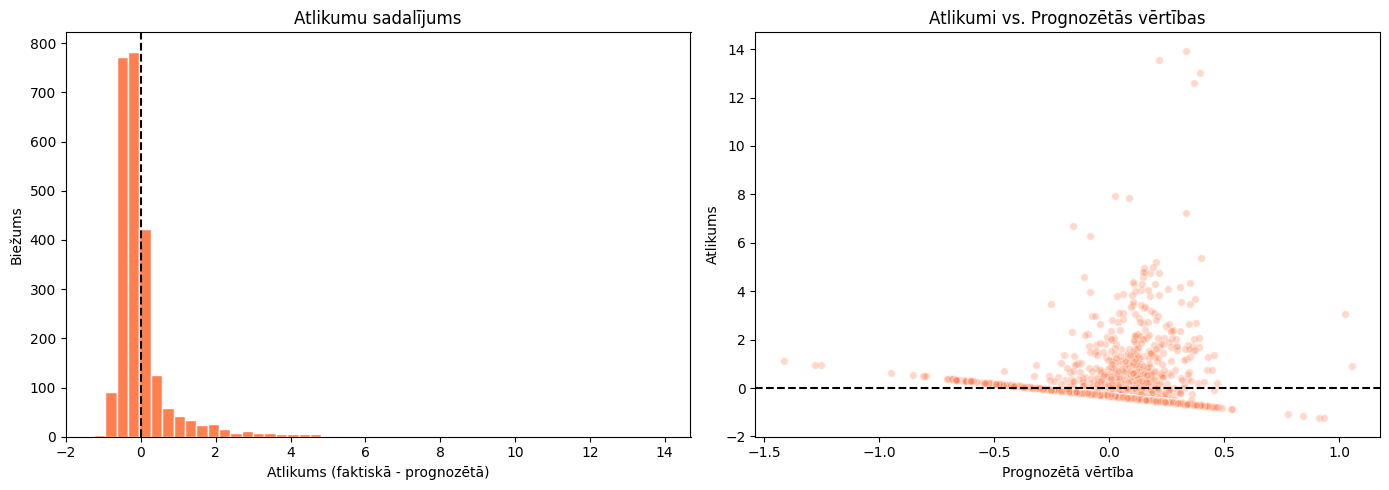

In [5]:
# 3.2. Atlikumu (residuals) analīze
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Atlikumu sadalījums
axes[0].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[0].set_title('Atlikumu sadalījums')
axes[0].set_xlabel('Atlikums (faktiskā - prognozētā)')
axes[0].set_ylabel('Biežums')
axes[0].axvline(x=0, color='black', linestyle='--')

# Atlikumi vs. prognozētās vērtības
axes[1].scatter(y_pred, residuals, alpha=0.3, color='coral', edgecolors='white', s=30)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title('Atlikumi vs. Prognozētās vērtības')
axes[1].set_xlabel('Prognozētā vērtība')
axes[1].set_ylabel('Atlikums')

plt.tight_layout()
plt.show()

Vizualizāciju interpretācija (Lineārā regresija) -
Vai punkti scatter grafikā ir tuvu sarkanai līnijai? Ko tas nozīmē?Nē, punkti nepavisam nav tuvu sarkanajai ideālās prognozes līnijai. Tie drīzāk veido horizontālu svītru ap nulli. Tas nozīmē, ka modelis nespēj noķert sakarības un gandrīz visiem klientiem prognozē PageValues tuvu nullei, neskatoties uz to, kāda ir faktiskā vērtība.Vai atlikumi ir vienmērīgi sadalīti ap 0? Vai ir kāds skaidrs modelis (pattern)?Atlikumi nav vienmērīgi sadalīti. "Atlikumi vs Prognozētās vērtības" grafikā ir ļoti skaidri redzama struktūra un raksts (pattern). Ja modelis būtu labs, šajā grafikā punkti izskatītos kā nejauši izmētāts mākonis, bet šeit redzamais raksts nozīmē, ka lineārās regresijas modelis pārkāpj savus pamatprincipus un netiek galā ar datiem.Ko vizualizācijas stāsta par modeļa kvalitāti?Grafiki kalpo kā vizuāls apstiprinājums ļoti zemajam $R^2$ rādītājam. Modelis ir zemas kvalitātes un nav piemērots šīs e-komercijas problēmas risināšanai, tāpēc mums būs jāizmanto cits, sarežģītāks algoritms.

In [6]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

# Metrikas
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Random Forest Regressor: rezultāti ===")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²: {r2_rf:.4f}")

=== Random Forest Regressor: rezultāti ===
RMSE: 0.9818
R²: 0.0698


In [7]:
comparison = pd.DataFrame({
    'Modelis': ['Lineārā regresija', 'Random Forest'],
    'RMSE': [rmse, rmse_rf],
    'R2': [r2, r2_rf]
})
print(comparison.to_string(index=False))

          Modelis     RMSE       R2
Lineārā regresija 0.994572 0.045556
    Random Forest 0.981844 0.069828


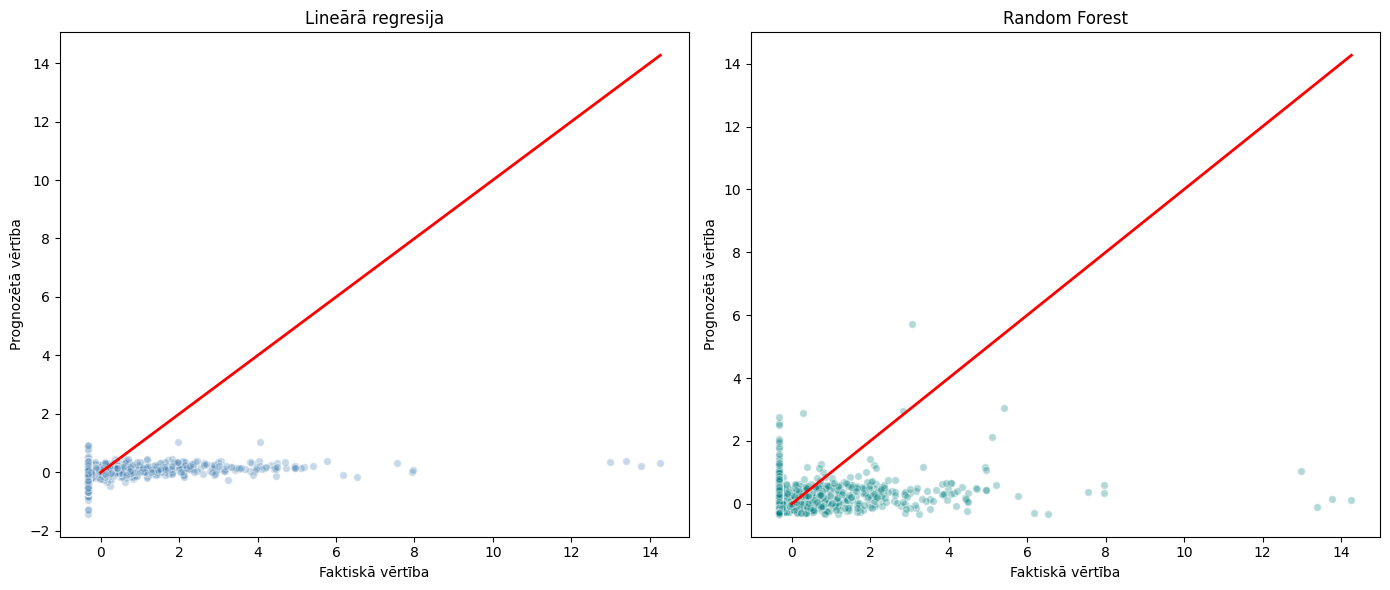

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, pred, title, color in [
    (axes[0], y_pred, 'Lineārā regresija', 'steelblue'),
    (axes[1], y_pred_rf, 'Random Forest', 'teal')
]:
    ax.scatter(y_test, pred, alpha=0.3, color=color, edgecolors='white', s=30)
    # max_val mēs definējām iepriekšējā uzdevumā
    ax.plot([0, max_val], [0, max_val], 'r', linewidth=2)
    ax.set_xlabel('Faktiskā vērtība')
    ax.set_ylabel('Prognozētā vērtība')
    ax.set_title(title)

plt.tight_layout()
plt.show()

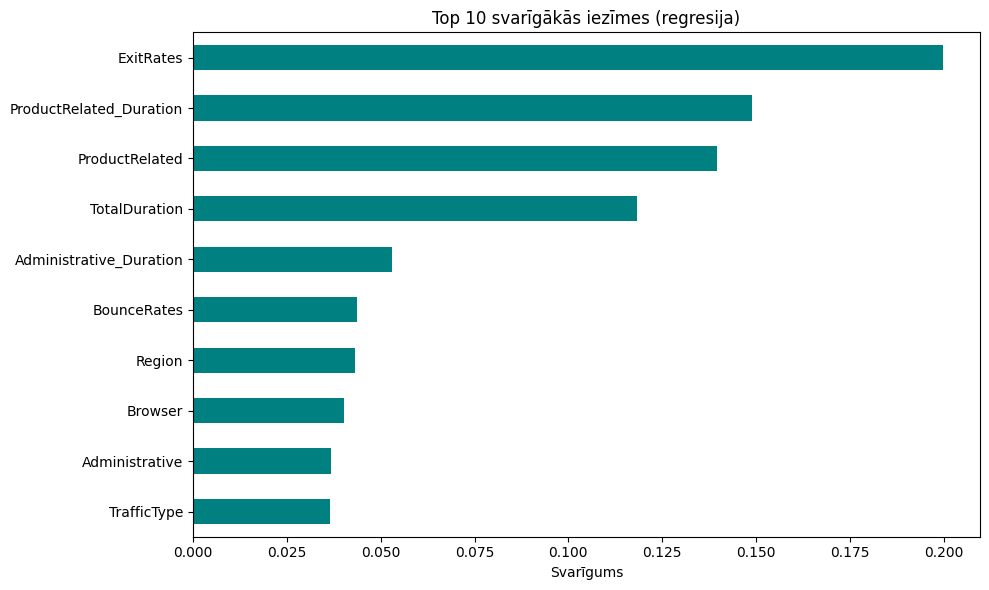

In [9]:
# Feature importance
importances = rf_reg.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 svarīgākās iezīmes (regresija)')
plt.xlabel('Svarīgums')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Secinājumi par modeļiem un iezīmēm -
Kurš modelis labāk prognozē PageValues un kāpēc?
Random Forest modelis strādā nedaudz labāk. Tā R² rādītājs ir augstāks (0.0698 pret 0.0456) un RMSE ir zemāks. Skatoties uz vizuālo salīdzinājumu, redzams, ka Random Forest spēj uztvert vismaz dažas sarežģītākas sakarības un mēģina prognozēt arī augstākas vērtības, kamēr lineārā regresija izteikti velk horizontālu līniju ap nulli. Tomēr kopumā abu modeļu spēja precīzi noteikt lapas vērtību šajā datu kopā ir vāja.

Kuras iezīmes visvairāk ietekmē pirkuma vērtību?
Saskaņā ar "Feature Importance" grafiku, vislielākā ietekme ir ExitRates (pamešanas rādītājam), kam cieši seko ar produktiem saistīto lapu pārlūkošanas ilgums (ProductRelated_Duration un TotalDuration), kā arī apskatīto produktu skaits (ProductRelated). Tas ir loģiski – jo ilgāk klients pēta produktus un jo mazāka ir varbūtība, ka viņš pametīs lapu, jo augstāka varētu būt viņa sesijas vērtība.

Biznesa izmantojums:
Ja es būtu e-komercijas analītiķis, es izmantotu šīs (pat ja ne pārāk precīzās) prognozes, lai identificētu "augsta potenciāla" sesijas reāllaikā. Redzot, ka klients sāk aktīvi un ilgi pētīt produktus (pieaug ProductRelated_Duration), sistēma varētu automātiski piedāvāt personalizētu palīdzību (chat-bot) vai īpašu atlaidi, lai maksimāli palielinātu izredzes, ka šī vērtīgā sesija noslēdzas ar reālu pirkumu.

Mans gala projekts
1. Problēma
Kādu jautājumu es gribu atbildēt ar ML?
Es vēlos prognozēt, kurš no 5 populārākajiem defektu veidiem ir konstatēts uz vēja turbīnas spārna, balstoties uz tā izmēru, lokāciju un turbīnas specifikāciju. Biznesa mērķis ir izveidot automatizētu kvalitātes kontroles (QA) rīku. Ja modelis konstatēs, ka operatora ievadītais defekta tips ievērojami atšķiras no modeļa prognozes (piemēram, operators atzīmē Delamination, bet dati liecina, ka 99% gadījumu šādā vietā ir Lightning Strike), inspekcija tiks atzīmēta pārbaudei, tā mazinot cilvēciskās kļūdas.

2. Datu kopa
Kādu datu kopu es izmantošu?
Uzņēmuma iekšējā vēja turbīnu spārnu inspekcijas reālo datu kopa. Tā tiks iepriekš filtrēta, atstājot rindas tikai ar 5 biežāk sastopamajiem defektu tipiem.

3. ML pieeja
Klasifikācija / Regresija / Klasterizācija? Kāpēc?
Klasifikācija (konkrētāk – Multiklašu klasifikācija). Tāpēc, ka mērķa mainīgais (Target) ir Defect type, kas ir kategoriska vērtība, kura var pieņemt 5 konkrētus stāvokļus, nevis nepārtraukts skaitlis.

4. Plānotās metrikas
Kā es mērīšu, vai modelis strādā?
Izmantošu F1 Score un Confusion Matrix. Tā kā defektu biežums var atšķirties (klašu disbalanss), F1 Score parādīs patieso modeļa precizitāti daudz labāk nekā parastā Accuracy. Savukārt Confusion Matrix ļaus vizuāli identificēt, kurus defektus (klases) modelis visbiežāk jauc savā starpā.

5. Datu sagatavošana
Kādus soļus veikšu?

Izfiltrēšu datu kopu, atstājot tikai Top 5 defektu veidus.

Izmetīšu nevajadzīgās identifikatoru kolonnas (Anomaly ID, Project nam, turbine_id, finalized_by), kas varētu radīt "datu noplūdi" vai troksni.

Apstrādāšu trūkstošās (null) vērtības.

Tekstuālās kategorijas (kā Rib, Side, Turbine model) pārveidošu skaitliskā formātā, izmantojot kodēšanu (piem., One-Hot Encoding), lai modeļi spētu tās apstrādāt.

6. Plānotie modeļi
Kādus algoritmus salīdzināšu?
Salīdzināšu 3. nedēļā apgūtos klasifikatorus: Decision Tree, Random Forest un Logistic Regression. Pievērsīšu īpašu uzmanību tam, kā Random Forest spēj atlasīt svarīgākās iezīmes (Feature Importance) liela datu apjoma apstākļos.

5.2. Pašnovērtējums

Vai mana problēma ir skaidri definēta un atbildama ar ML? Jā, mērķis (defekta tips) un ieejas dati (lokācija, izmēri) ir skaidri un loģiski saistīti.


Vai man ir piemērota datu kopa? Jā, man ir reāla darba datu kopa ar tūkstošiem rindu un skaidru kategorisko marķējumu.


Vai es zinu, kādu metriku izmantošu un kāpēc? Jā, izmantošu F1 Score, lai cīnītos ar datu disbalansu, un kļūdu matricu dziļākai analīzei.